<a href="https://colab.research.google.com/github/fernandolievano/aprendizaje-automatico-1/blob/main/TP2_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TRABAJO PRÁCTICO DE CLUSTERING: CONSIGNAS

**Fernando Javier García Liévano**

## Utilizando solo Numpy y Scikit-learn, y opcionalmente Pandas y Matplotlib, debes realizar  lo siguiente sobre el conjunto de datos de California Housing:




### Instalación de librerías

In [24]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Utils y variables

In [4]:
def print_heading(title: str):
    line = "=" * 90
    print(line)
    print(f" 🟦 {title.upper()}")
    print(line)
    print("\n")

## 1. Analiza los datos, inspecciona todas las características y el target.

**Explica de que trata el dataset, cada una de sus variables**

**Asegúrate de preparar los datos para utilizarse en modelos  predictivos.**

**Puedes hacer el preprocesamiento de características  (selección, transformación) que consideres más adecuado, justificar.**

Fuente del dataset: https://www.kaggle.com/datasets/camnugent/california-housing-prices

### 1.1 Carga del dataset y vista general

In [5]:
# Descarga la última versión del dataset
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'california-housing-prices' dataset.
Path to dataset files: /kaggle/input/california-housing-prices


In [6]:
! ls /root/.cache/kagglehub/datasets/camnugent/california-housing-prices/versions/1

ls: cannot access '/root/.cache/kagglehub/datasets/camnugent/california-housing-prices/versions/1': No such file or directory


In [7]:
files_in_path = os.listdir(path)
print(f"--> Archivos en el directorio {path}: {files_in_path}. \n")
ruta_al_archivo = path + "/" +files_in_path[0]

print(f"--> Cargando datos desde : {ruta_al_archivo}.\n")
df = pd.read_csv(ruta_al_archivo)

print("--> DataFrame 'df' creado. Muestro las primeras 5 filas: \n")
display(df.head())


--> Archivos en el directorio /kaggle/input/california-housing-prices: ['housing.csv']. 

--> Cargando datos desde : /kaggle/input/california-housing-prices/housing.csv.

--> DataFrame 'df' creado. Muestro las primeras 5 filas: 



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
print_heading('Analizamos forma e información del dataset')
df.info()

 🟦 ANALIZAMOS FORMA E INFORMACIÓN DEL DATASET


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


> ℹ El dataset cuenta con 2,0640 filas y con 10 columnas. Tenemos a `ocean_proximity` como única variable categórica y el resto son numéricas. Y podemos notar que en la variable `total_bedrooms` tenemos valores faltantes.

### 1.2 Descripción del Dataset

**¿De qué trata el Dataset?**

El dataset en general nos da información sobre las casas ubicadas en distritos de California. Una cosa a tener en cuenta es que el dataset no nos da información sobre casas individuales, sino de bloques de casas.

Entre las variables del dataset tenemos: coordenadas geográficas, cantidad total de habitaciones y dormitorios por bloque, población, media de ingresos de los hogares, media de valores de las viviendas y proximidad al océano.


**Inspeccionamos las características**

- **longitude** y **latitude**: coordenadas geográficas correspondientes a cada bloque de casas.
- **housing_median_age**: mediana de antigüedad de las casas en un bloque.
- **total_rooms**: número total de habitaciones en un bloque.
- **total_bedrooms**: número total de dormitorios en un bloque.
- **population**: número total de personas que residen en un bloque de casas.
- **households**: número total de hogares, es decir, casas ocupadas dentro del bloque.
- **median_income**: ingreso mediano de las casas en el bloque.
- **median_house_value**: valor mediano de las casas del bloque.
- **ocean_proximity**: variable categórica que indica la cercanía del bloque de casas al océano.

> ℹ Todas son variables numéricas, salvo `ocean_proximity` que es categórica

### 1.3 Análisis exploratorio

**1.3.1 Análisis de nulos**

In [9]:
print_heading('Cantidad de nulos por columna')
print(df.isnull().sum())
print('-' * 90)

null_percentage = ((df['total_bedrooms'].isnull().mean()) * 100).round(2)

print(f"\n -> La única columna con nulos es 'total_bedrooms, con 207 valores faltantes, \n lo que representa un {null_percentage}% del dataset.")

 🟦 CANTIDAD DE NULOS POR COLUMNA


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
------------------------------------------------------------------------------------------

 -> La única columna con nulos es 'total_bedrooms, con 207 valores faltantes, 
 lo que representa un 1.0% del dataset.


> ℹ 1% de +20k registros es un porcentaje poco significante, pero para evitar perder información vamos a imputar con la mediana.

**1.3.2 Resumen Estadístico**

In [10]:
stats = df.describe().T
stats.rename(columns={'50%': 'median'}, inplace=True) # renombro para que sea más fácil de identificar la mediana
stats.round(2)

,count,mean,std,min,25%,median,75%,max
longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
total_rooms,20640.0,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00
total_bedrooms,20433.0,537.87,421.39,1.00,296.00,435.00,647.00,6445.00
population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
households,20640.0,499.54,382.33,1.00,280.00,409.00,605.00,6082.00
median_income,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
median_house_value,20640.0,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00


> ℹ Al analizar los estadísticos, se identificó la posible presencia de outliers en la variable `total_rooms`, podemos notarlo en la brecha que hay entre la media y la mediana, y además viendo la distancia entre el valor máximo y el tercer cuartil.


**1.3.3 Distribución de variables**

 🟦 DISTRIBUCIÓN DE VARIABLES CLAVE




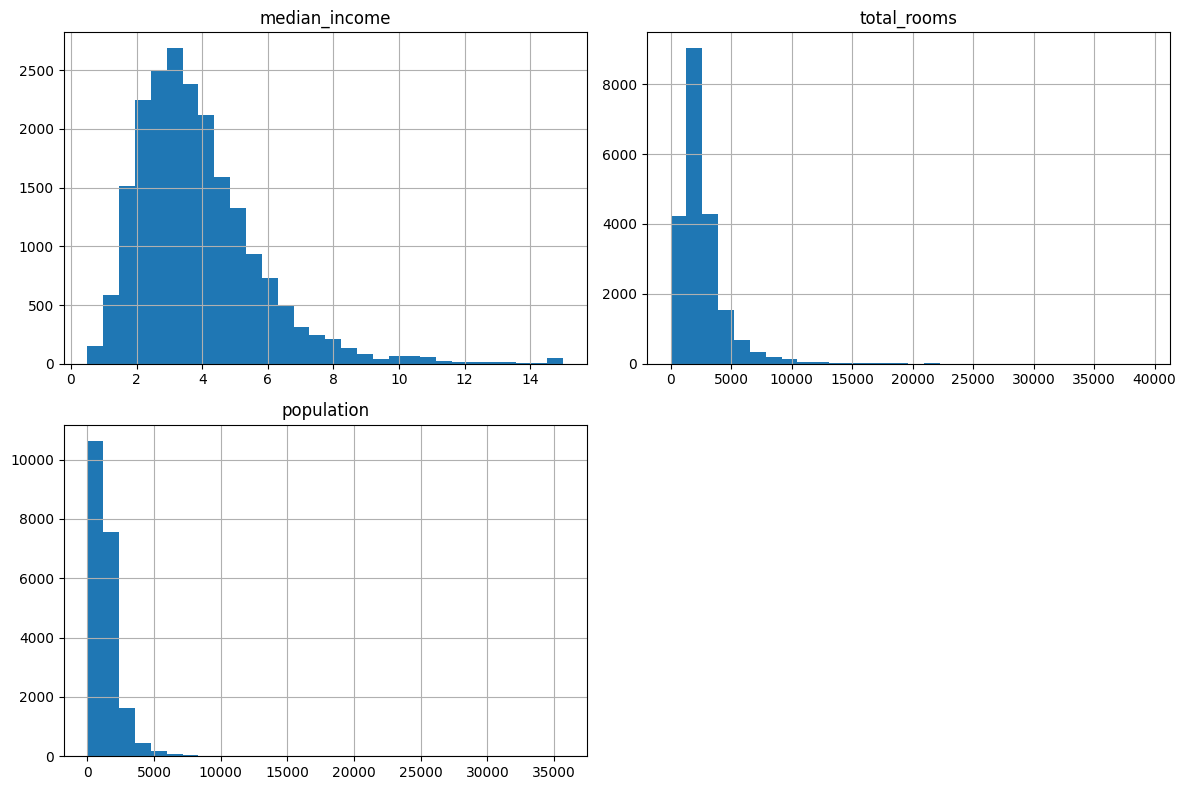

In [11]:
print_heading('Distribución de variables clave')

cols = ['median_income', 'total_rooms', 'population']

df[cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

> ℹ Se seleccionaron `median_income`, `total_rooms` y `population` por ser variables que representan aspectos importantes de dataset: economía, estructura y demografía, lo que nos va a permitir entender mejor el dataset y observar patrones en la distribución de los datos.
>
> Podemos observar asimetría positiva en las variables con presencia de algunos valores extremos principalmente en `total_rooms` y `population`.

**1.3.4 Escala de variables**

> ℹ Algunas variables presentan diferentes órdenes de magnitud (comparando `median_income` con `total_rooms`). Si no se llegara a aplicar escalado, esto sería un problema ya que sesgaría la formación de los clusters.

**1.3.5 Relación entre variables**

 🟦 RELACIÓN ENTRE VARIABLES




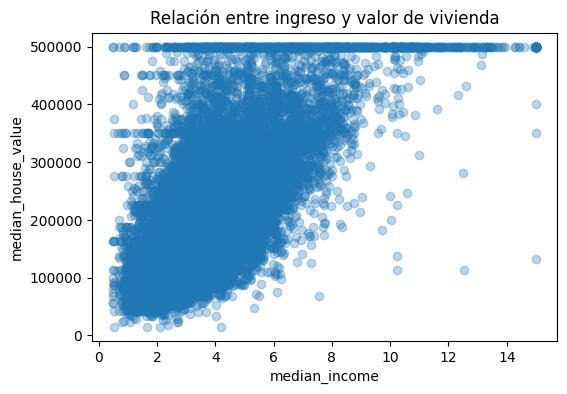

In [12]:
print_heading('Relación entre variables')

plt.figure(figsize=(6,4))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.3)
plt.xlabel('median_income')
plt.ylabel('median_house_value')
plt.title('Relación entre ingreso y valor de vivienda')
plt.show()

> ℹ En el gráfico podemos apreciar que hay una **relación positiva** entre el ingreso medio y el valor de vivienda. Pero, existe dispersión en los datos, lo que nos dice que hay otras variables influyendo en la determinación del precio.
>
> Otro detalle a tener en cuenta es que existe un límite superioren los valores de las casas, puede llegar a influir en el análisis.

### 1.4 Preprocesamiento de datos

**1.4.1 Tratamiento de valores faltantes**

Durante la exploración de datos detectamos un 1% de valores faltantes en la columna `total_bedrooms`. Dado que el porcentaje de datos faltantes es muy bajo, se decidió imputarlos utilizando la mediana, ya que nos ayuda a minimizar el impacto en la distribución de la variable.*texto en cursiva*

In [13]:
print_heading('Tratamiento de nulos')

df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

df.isnull().sum()

 🟦 TRATAMIENTO DE NULOS




,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


> ℹ Se verificó y se confirmó que no quedan valores faltantes en el dataset

**1.4.2 Selección de variables**

Durante esta etapa seleccionamos las variables a utilizar para el análisis.

Para comenzar, vamos a descartar la variable categórica `ocean_proximity` que será transformada posteriormente para poder ser incluida en el modelo. Ya que los algoritmos de clustering trabajan con distancias, vamos a priorizar las variables numéricas.

Por otro lado, la variable `median_house_value` no será utilizada para el entrenamiento ya que no se trata de un problema supervisado.



**1.4.3 Transformación de variables numéricas**

A partir de anáisis exploratorio se observó que algunas variables presentan cierto nivel de sesgo, principalmente las variables relacionadas con conteos, como `total_rooms`, `total_bedrooms`, `population` y `households`.

Para reducir la asimetría presentada, vamos a aplicar transformación logarítmica sobre dichas variables, lo que permite suavizar los valores extremos y así mejorar la distribución de los datos.



In [20]:
print_heading('Calculando transformación logarítmica de variables')

# calcular las transformaciones logarítmicas y guardarlas en series temporales
# np.log1p para manejar ceros (si los hubiera)
total_rooms_log_series = np.log1p(df['total_rooms'])
total_bedrooms_log_series = np.log1p(df['total_bedrooms'])
population_log_series = np.log1p(df['population'])
households_log_series = np.log1p(df['households'])

display(pd.DataFrame({
    'total_rooms_log': total_rooms_log_series,
    'total_bedrooms_log': total_bedrooms_log_series,
    'population_log': population_log_series,
    'households_log': households_log_series
}).head().round(2))

 🟦 CALCULANDO TRANSFORMACIÓN LOGARÍTMICA DE VARIABLES




,total_rooms_log,total_bedrooms_log,population_log,households_log
0,6.78,4.87,5.78,4.84
1,8.87,7.01,7.78,7.04
2,7.29,5.25,6.21,5.18
3,7.15,5.46,6.33,5.39
4,7.40,5.64,6.34,5.56


**1.4.4 Codificación de variables categóricas**

Se procederá a tratar la variable `ocean_proximity` mediante One-Hot Encoding  para que pueda ser tratada por los algoritmos de clustering, ya que al ser una variable categórica no tiene una representación numérica válida.



In [22]:
print_heading('Calculando One-Hot Encoding para ocean_proximity')

# instancia del OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# ajustar y transformar la columna 'ocean_proximity'
ocean_proximity_encoded = ohe.fit_transform(df[['ocean_proximity']])

# crear un DataFrame con las columnas codificadas
ocean_proximity_df = pd.DataFrame(
    ocean_proximity_encoded,
    columns=ohe.get_feature_names_out(['ocean_proximity']),
    index=df.index
)

print("-> One-Hot Encoding calculado para 'ocean_proximity'")
display(ocean_proximity_df.head())

 🟦 CALCULANDO ONE-HOT ENCODING PARA OCEAN_PROXIMITY


-> One-Hot Encoding calculado para 'ocean_proximity'


,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0


**1.4.5 Escalado de variables**

El escalado de variables es esencial en algoritmos basados en la distancia como K-means. Al aplicar StandardScaler, nos aseguramos de que todas las características contribuyan equitativamente a la formación de los clústeres, evitando que variables con rangos mayores dominen indebidamente el cálculo de distancias.

In [31]:
print_heading('Creando dataFrame de características X y aplicamos escalado')

# columnas numéricas originales de df a incluir directamente en X
numerical_features = [
    'longitude', 'latitude', 'housing_median_age', 'median_income'
]

# crear el DataFrame X inicial con las características numéricas originales
X = df[numerical_features].copy()

# añadir las variables logarítmicas calculadas previamente como nuevas columnas en X
X['total_rooms_log'] = total_rooms_log_series
X['total_bedrooms_log'] = total_bedrooms_log_series
X['population_log'] = population_log_series
X['households_log'] = households_log_series

# concatenar las columnas One-Hot Encoded de ocean_proximity_df a X
X = pd.concat([X, ocean_proximity_df], axis=1)

# inicializamos el escalador
scaler = StandardScaler()

# aplicamos el escalado a todas las columnas en X
X_scaled_array = scaler.fit_transform(X)

# convertimos el array escalado de nuevo a un DataFrame, manteniendo los nombres de las columnas
X = pd.DataFrame(X_scaled_array, columns=X.columns, index=X.index)

print("-> DataFrame 'X' creado con las características seleccionadas, transformadas y escaladas.")
display(X.head())

print(f"\n->  Forma de X: {X.shape}")

 🟦 CREANDO DATAFRAME DE CARACTERÍSTICAS X Y APLICAMOS ESCALADO


-> DataFrame 'X' creado con las características seleccionadas, transformadas y escaladas.


,longitude,latitude,housing_median_age,median_income,total_rooms_log,total_bedrooms_log,population_log,households_log,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327835,1.052548,0.982143,2.344766,-1.131133,-1.642192,-1.694943,-1.569395,-0.891156,-0.681889,-0.015566,2.830742,-0.384466
1,-1.322844,1.043185,-0.607019,2.332238,1.651357,1.320043,1.030337,1.449251,-0.891156,-0.681889,-0.015566,2.830742,-0.384466
2,-1.332827,1.038503,1.856182,1.782699,-0.450310,-1.110094,-1.109604,-1.104849,-0.891156,-0.681889,-0.015566,2.830742,-0.384466
3,-1.337818,1.038503,1.856182,0.932968,-0.638257,-0.817506,-0.949925,-0.813343,-0.891156,-0.681889,-0.015566,2.830742,-0.384466
4,-1.337818,1.038503,1.856182,-0.012881,-0.312370,-0.576140,-0.933021,-0.583469,-0.891156,-0.681889,-0.015566,2.830742,-0.384466



->  Forma de X: (20640, 13)


## 2. Realiza un clustering sobre los datos con K-means, separándolos en un número manejable de  grupos (de 2 a 10).

2.1) Justifica cuál métrica ( o grupo de métricas) utilizas para determinar el valor de k.

2.2) Realiza un análisis descriptivo de cada clúster, grafica para cada uno diagrama cajas.



## 3. Aplica DB-SCAN sobre el mismo dataset que utilizaste en el punto 2.

Realiza una interpretación de su aplicación y un análisis de los resultados obtenidos.

# NO OLVIDES

Agregar tus conclusiones y referencias.